# Explore manually downloaded ESS10

In [1]:
import pandas as pd

file_path = r"C:\Users\charlott\Dropbox (Personal)\Paper_Finn_Lotti\Data\ESS 10\ESS10.csv"
data = pd.read_csv(file_path)

# Which countries?
unique_countries = data['cntry'].unique()
print(unique_countries)

# List of labels (column names) of all variables
labels_list = data.columns.tolist()
print(labels_list)

C:\Users\charlott\AppData\Local\Temp\ipykernel_28912\2853790080.py:4: DtypeWarning: Columns (169,175,177,610,611) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


['BE' 'BG' 'CH' 'CZ' 'EE' 'FI' 'FR' 'GB' 'GR' 'HR' 'HU' 'IE' 'IS' 'IT'
 'LT' 'ME' 'MK' 'NL' 'NO' 'PT' 'SI' 'SK']
['name', 'essround', 'edition', 'proddate', 'idno', 'cntry', 'dweight', 'pspwght', 'pweight', 'anweight', 'prob', 'stratum', 'psu', 'nwspol', 'netusoft', 'netustm', 'ppltrst', 'pplfair', 'pplhlp', 'polintr', 'psppsgva', 'actrolga', 'psppipla', 'cptppola', 'trstprl', 'trstlgl', 'trstplc', 'trstplt', 'trstprt', 'trstep', 'trstun', 'trstsci', 'vote', 'prtvtebe', 'prtvtebg', 'prtvthch', 'prtvtbhr', 'prtvtecz', 'prtvthee', 'prtvtefi', 'prtvtefr', 'prtvtdgr', 'prtvtghu', 'prtvtdis', 'prtvtdie', 'prtvtdit', 'prtvclt1', 'prtvclt2', 'prtvclt3', 'prtvtame', 'prtvthnl', 'prtvtmk', 'prtvtbno', 'prtvtdpt', 'prtvtfsi', 'prtvtesk', 'prtvtdgb', 'contplt', 'donprty', 'badge', 'sgnptit', 'pbldmna', 'bctprd', 'pstplonl', 'volunfp', 'clsprty', 'prtclebe', 'prtclebg', 'prtclhch', 'prtclbhr', 'prtclecz', 'prtclhee', 'prtclffi', 'prtclffr', 'prtcldgr', 'prtclhhu', 'prtcldis', 'prtclfie', 'prtcleit

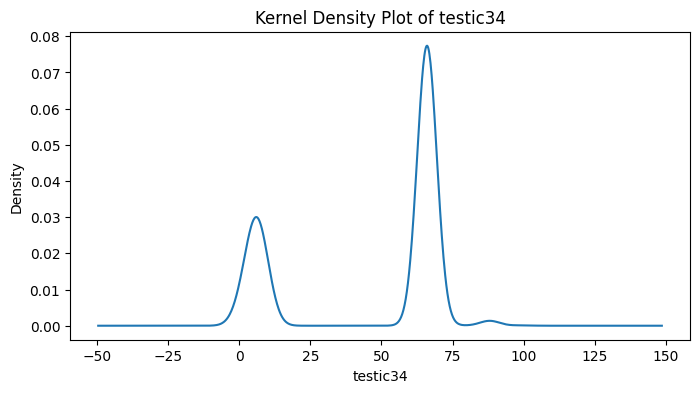

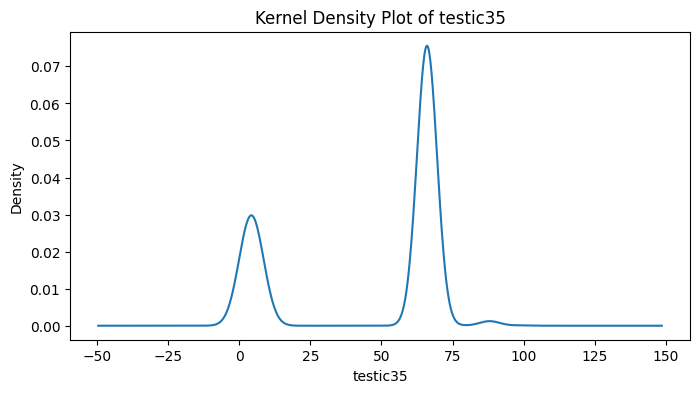

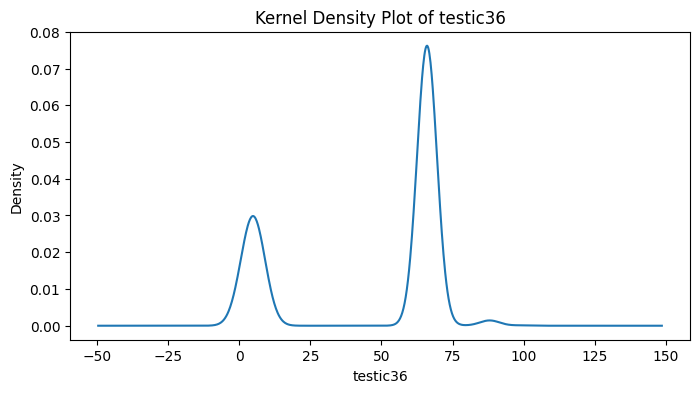

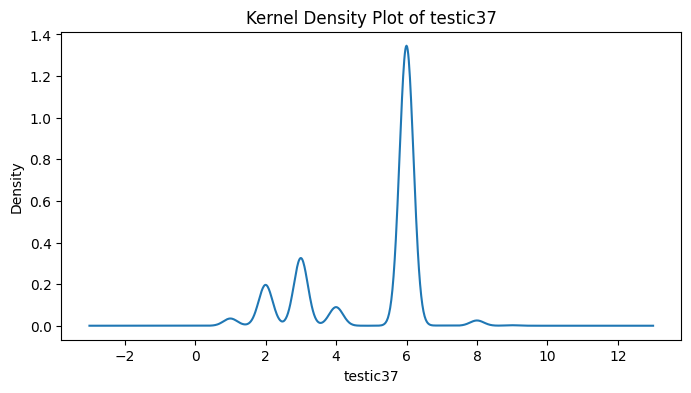

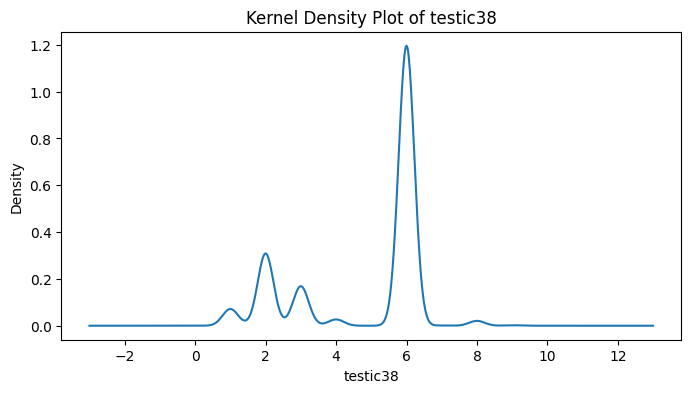

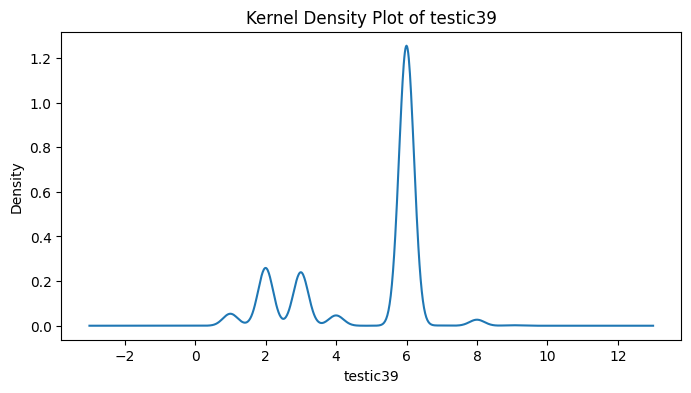

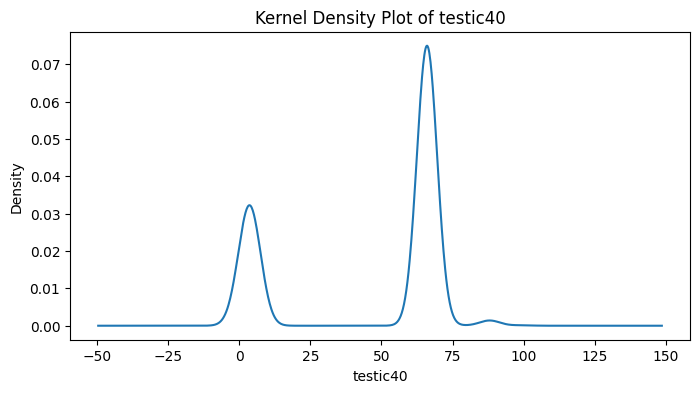

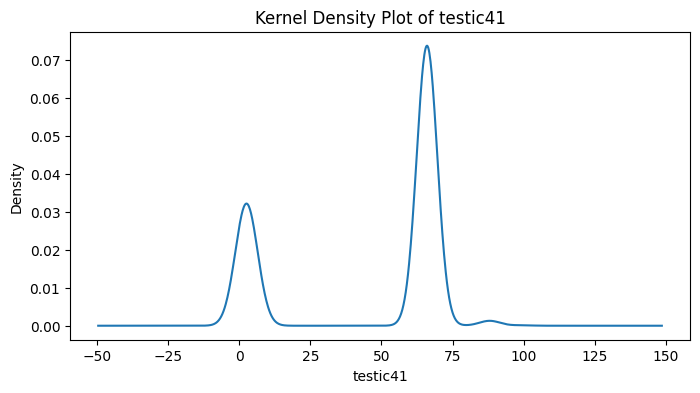

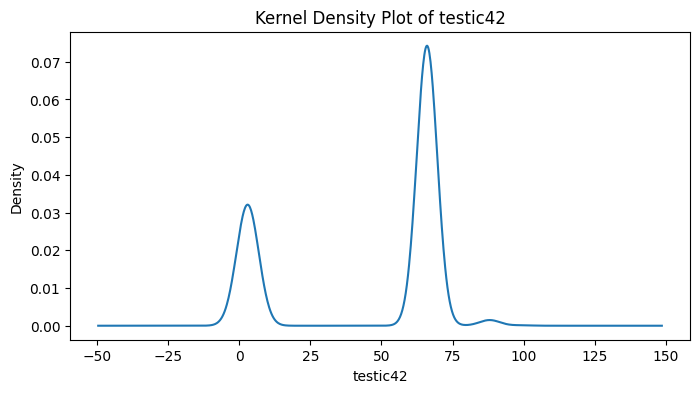

In [8]:
import matplotlib.pyplot as plt

#Kdensities of questions around climate policy
testic_columns = [col for col in data.columns if col.startswith('testic')]

for col in testic_columns:
    plt.figure(figsize=(8, 4))  # Set the figure size
    data[col].plot(kind='kde', title=f'Kernel Density Plot of {col}')  # Create k-density plot
    plt.xlabel(col)  # Set x-axis label as column name
    plt.show()  # Show the plot for each column

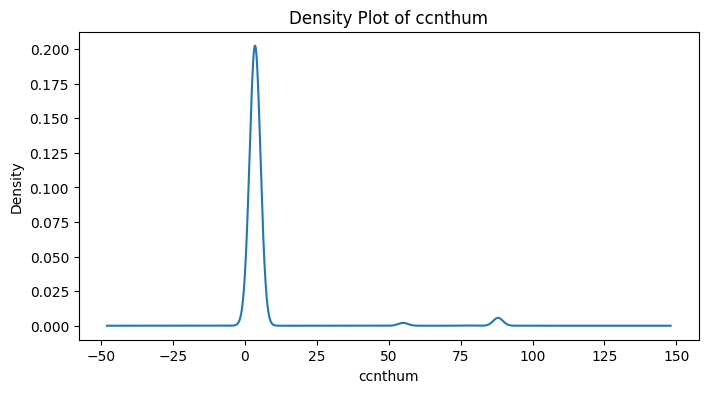

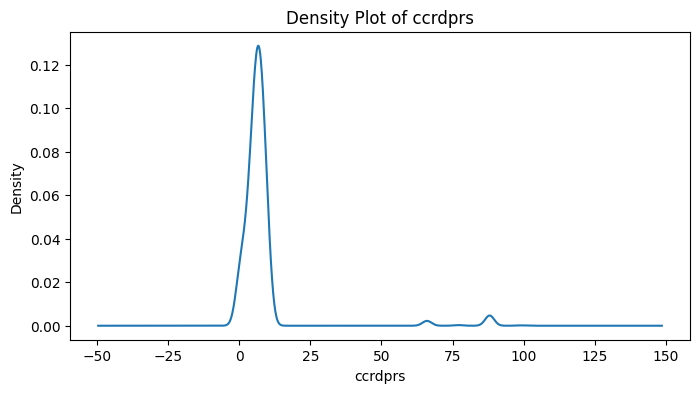

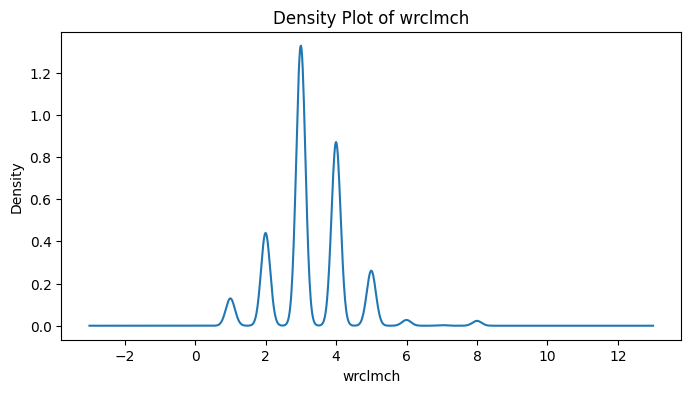

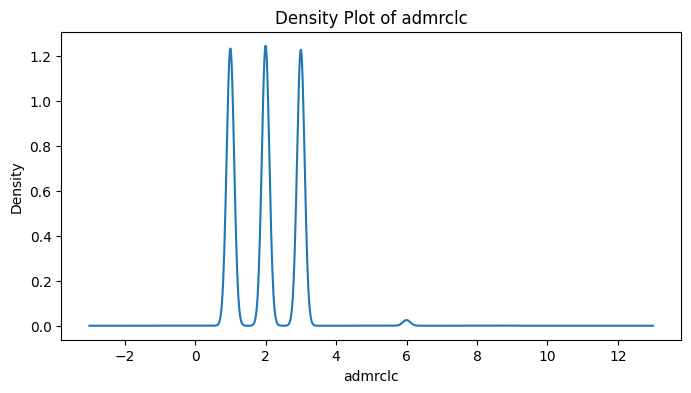

In [10]:
# Other cc questions
variables = ['ccnthum', 'ccrdprs', 'wrclmch', 'admrclc']

# Create density plots for the selected variables
for variable in variables:
    plt.figure(figsize=(8, 4))  # Set the figure size
    data[variable].plot(kind='density', title=f'Density Plot of {variable}')  # Create density plot
    plt.xlabel(variable)  # Set x-axis label as variable name
    plt.show()  # Show the plot for each variable


In [7]:
##  Detect any open-ended questions in ESS 

exclude_variables = ['idno', 'cntry', 'dweight', 'pspwght', 'anweight', 'prob', 'pweight', 'psu', 'stratum']
variables_to_check = [col for col in data.columns if col not in exclude_variables]

# Check the number of unique values for each column
unique_counts = data[variables_to_check].nunique()

# Identify variables with more than 15 unique values
variables_with_more_than_15_values = unique_counts[unique_counts > 600]

# Exclude variables ending with "we", "ws", or "de"
variables_with_more_than_15_values = variables_with_more_than_15_values[~variables_with_more_than_15_values.index.str.endswith(('we', 'ws', 'de'))]

# Print the results
print("Variables with more than 15 unique values (excluding specified variables):")
print(variables_with_more_than_15_values)

Variables with more than 15 unique values (excluding specified variables):
inwds    37335
dtype: int64


## https://github.com/fsentin/ess/blob/main/ESS-dashboard.py

In [6]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:


from dash import Dash, dcc, html, Input, Output
import dash_bootstrap_components as dbc
import plotly.express as px
import pandas as pd
import numpy as np
import chart_studio.plotly as py
import plotly.graph_objects as go
import cufflinks as cf
import seaborn as sns
import plotly.express as px
import matplotlib as plt
import json
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

round10 = pd.read_csv('round10_ready.csv')
round9 = pd.read_csv('round9_ready.csv')
round8 = pd.read_csv('round8_ready.csv')


round10.head()


# In[2]:


r10 = round10.drop(['Code', 'Country'], axis=1)
r10.index = round10['Country']
r9 = round9.drop(['Code', 'Country'], axis=1)
r9.index = round9['Country']
r8 = round8.drop(['Code', 'Country'], axis=1)
r8.index = round8['Country']


# In[3]:


attrs = ['Happiness','Satisfaction with life','Religiousness','Emotional attachment to ones country','Emotional attachment to Europe','Feeling of safety walking alone after dark','Trust in the legal system','Trust in the police','Trust in politicians','Perceived state of health services in country nowadays',
'Perceived state of education in country nowadays']


# In[4]:


def create_barplots(round_data, attr):
    fig = px.bar(round_data, x='Country', y=attr,
             hover_data=['Country', attr], color=attr, color_continuous_scale="plasma"
                )
    fig.update_layout(xaxis={'categoryorder':'total descending'})
    fig.update(layout_coloraxis_showscale=False)
    fig.update_layout(plot_bgcolor = "white")
    return fig

def create_choropleths(round_data, attr):
    fig = px.choropleth(round_data, locations='Country', color=attr, scope='europe', locationmode= 'country names', 
                    hover_data=['Country', attr], color_continuous_scale="plasma")                         
    fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
    return fig

def create_pca_plots(round_data):
    sc = StandardScaler()
    r_s = sc.fit_transform(round_data)
    pca = PCA(n_components = 2)
    proj = pca.fit_transform(r_s)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    fig = px.scatter(proj, x=0, y=1, text=round_data.index, color_discrete_sequence=["white"],
                labels={
                     "0": "1st primary component",
                     "1": "2nd primary component"
                 })
    fig.update_layout(plot_bgcolor = "white", margin={"r":10,"t":10,"l":10,"b":10})
    return fig

def create_pca_plots_attrs(round_data, attr):
    sc = StandardScaler()
    r_s = sc.fit_transform(round_data)
    pca = PCA(n_components = 2)
    proj = pca.fit_transform(r_s)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    #print(proj)
    fig = px.scatter(proj, x=0, y=1,  color_discrete_sequence=["black"], hover_data={"Country":round_data.index}, 
                labels={
                     "0": "1st primary component",
                     "1": "2nd primary component"
                 })
    j = attrs.index(attr)
    for i, attr in enumerate(attrs):
        if i == j:

            col="#1c188e"
            wid = 3
            siz=15
        else:
            col="#d35070"
            wid = 1
            siz = 8
            
        fig.add_shape(
            type='line',
            x0=0, y0=0,
            x1=loadings[i, 0]*4.5,
            y1=loadings[i, 1]*4.5,
            line=dict(
            color=col, width=2)
        )
        fig.add_annotation(
            x=loadings[i, 0]*5,
            y=loadings[i, 1]*5,
            ax=0, ay=0,
            xanchor="center",
            yanchor="bottom",
            text=attr,
            font=dict(size=siz, color=col)
        )
    
    fig.update_layout(plot_bgcolor = "white", margin={"r":10,"t":10,"l":10,"b":10})
    return fig


# In[5]:


barfigs10 = []
barfigs9 = []
barfigs8 = []
chorofigs10 = []
chorofigs9 = []
chorofigs8 = []
pcafigs10 = []
pcafigs9 = []
pcafigs8 = []
pcafigs10attr = []
pcafigs9attr = []
pcafigs8attr = []

for i in attrs:
    barfigs10.append(create_barplots(round10, i))
    barfigs9.append(create_barplots(round9, i))
    barfigs8.append(create_barplots(round8, i))
    chorofigs10.append(create_choropleths(round10, i))
    chorofigs9.append(create_choropleths(round9, i))
    chorofigs8.append(create_choropleths(round8, i))
    pcafigs10.append(create_pca_plots(r10))
    pcafigs9.append(create_pca_plots(r9))
    pcafigs8.append(create_pca_plots(r8))
    pcafigs10attr.append(create_pca_plots_attrs(r10, i))
    pcafigs9attr.append(create_pca_plots_attrs(r9, i))
    pcafigs8attr.append(create_pca_plots_attrs(r8, i))


# In[6]:


app = Dash(__name__)
app.title = "European Social Survey"
app.layout = html.Div(children=[
    #html.H1(children="European Social Survey"),
    #html.P("The European Social Survey (ESS) is a cross-national survey which measures the attitudes, beliefs and behaviour patterns of different European populations through time."),
    html.Label(['Choose social aspect and year to explore:'],style={'font-weight': 'bold'}),
    html.Div(children=[
        dcc.Dropdown(
        options=['Happiness','Satisfaction with life','Religiousness','Emotional attachment to ones country','Emotional attachment to Europe','Feeling of safety walking alone after dark','Trust in the legal system','Trust in the police','Trust in politicians','Perceived state of health services in country nowadays',
'Perceived state of education in country nowadays'],
        value='Happiness', id='dropdown', style={'display': 'inline-block', "width": '400px'}),
        html.Div(style={'display': 'inline-block',"width": '5px'}),
    dcc.Dropdown(
        options=['2020','2018', '2016'],
        value='2020', id='dropdownyear', style={'display': 'inline-block',"width": '100px'}),
    ]),
    
    html.Br(),

    html.Div(children=[
                html.Span(children=dcc.Graph(id='bar'), style={'display': 'inline-block', "width": "50%"}),
                html.Span(children=dcc.Graph(id='choro'), style={'display': 'inline-block', "width": "50%"}),
                html.Br(),
                html.Span(children=dcc.Graph(id='pcaattr'), style={'display': 'inline-block', "width": "50%"}),
                html.Span(children=dcc.Graph(id='pca'), style={'display': 'inline-block', "width": "50%"}),
    ], style={'margin':'auto'}),
    
    
], style={'font-family':' Arial, Helvetica, sans-serif','font-size':'1em', 'width':'70%', 'margin':'auto'})

    
@app.callback(
    Output('bar', 'figure'),
    Output('choro', 'figure'),
    Output('pca', 'figure'),
    Output('pcaattr', 'figure'),
    Input('dropdown', 'value'),
    Input('dropdownyear', 'value')
)
def update_bar(attr, year):
    i = attrs.index(attr)
    if year=='2020':        
        return barfigs10[i], chorofigs10[i], pcafigs10[i], pcafigs10attr[i]
    elif year=='2018':
        return barfigs9[i], chorofigs9[i], pcafigs9[i], pcafigs9attr[i]
    else:
        return barfigs8[i], chorofigs8[i], pcafigs8[i], pcafigs8attr[i]

if __name__ == '__main__':
    app.run_server(debug=False)
